# YOLO pose inference and evaluation (test set with labels)

In [101]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.metrics import roc_curve, auc

## Parameters

In [102]:
PATH_MODEL = "./single_run.pt"
PATH_IMAGES = "../datasets/Lepidoptera/images/test"
PATH_LABEL = "../datasets/Lepidoptera/labels/test"

CSV_PATH = "results_test.csv"

CONF_THRESHOLD = 0.65      # global confidence: processable (>=) vs non processable (<)
METRIC_THRESHOLD = 0.9    # mAP: good (>=) vs bad (<) prediction

OKS_THRESHOLDS = np.arange(0.5, 1.0, 0.05)   # 0.50, 0.55, ..., 0.95
DEFAULT_SIGMA = 0.05                          # used when keypoint count != 17

IMG_CONF = 0.25           # detector confidence to keep a detection
DEVICE = None             # e.g. 0, "cpu", or None for automatic

## Helpers

In [103]:
# helpers...
# COCO keypoint sigmas (17 keypoints). Uniform value used otherwise.
COCO_SIGMAS = np.array([
    0.026, 0.025, 0.025, 0.035, 0.035, 0.079, 0.079, 0.072, 0.072,
    0.062, 0.062, 0.107, 0.107, 0.087, 0.087, 0.089, 0.089
])

def get_sigmas(num_kpts):
    if num_kpts == len(COCO_SIGMAS):
        return COCO_SIGMAS
    return np.full(num_kpts, DEFAULT_SIGMA)

def load_gt(label_path, img_w, img_h):
    # YOLO pose label: class cx cy w h x1 y1 v1 x2 y2 v2 ... (normalized)
    objs = []
    if not os.path.exists(label_path):
        return objs
    with open(label_path) as f:
        for line in f:
            vals = line.split()
            if len(vals) < 5:
                continue
            vals = list(map(float, vals))
            _, cx, cy, w, h = vals[:5]
            kpt_vals = vals[5:]
            k = len(kpt_vals) // 3
            kpts = np.array(kpt_vals[:k * 3]).reshape(k, 3)
            kpts[:, 0] *= img_w
            kpts[:, 1] *= img_h
            area = (w * img_w) * (h * img_h)
            objs.append({"kpts": kpts, "area": max(area, 1.0)})
    return objs

def oks_matrix(pred_xy, gts, sigmas):
    # pred_xy: (P, K, 2) in pixels -> returns (P, G) OKS values
    P = pred_xy.shape[0]
    G = len(gts)
    M = np.zeros((P, G))
    var = (sigmas * 2) ** 2
    for gi, gt in enumerate(gts):
        gk = gt["kpts"]
        vis = gk[:, 2] > 0
        if vis.sum() == 0:
            continue
        for pi in range(P):
            dx = pred_xy[pi, :, 0] - gk[:, 0]
            dy = pred_xy[pi, :, 1] - gk[:, 1]
            e = (dx ** 2 + dy ** 2) / var / (gt["area"] + np.spacing(1)) / 2
            M[pi, gi] = np.mean(np.exp(-e[vis]))
    return M

def compute_ap(recall, precision):
    # all-point interpolation (VOC style)
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

def image_map(pred_xy, pred_conf, gts, sigmas, oks_thrs):
    # per-image mAP averaged over OKS thresholds
    P = pred_xy.shape[0]
    G = len(gts)
    if G == 0:
        return np.nan          # no ground truth -> undefined
    if P == 0:
        return 0.0             # nothing detected -> everything missed
    M = oks_matrix(pred_xy, gts, sigmas)
    order = np.argsort(-pred_conf)
    aps = []
    for t in oks_thrs:
        matched = np.zeros(G, dtype=bool)
        tp = np.zeros(P)
        fp = np.zeros(P)
        for rank, p in enumerate(order):
            best_g, best_oks = -1, t
            for g in range(G):
                if matched[g]:
                    continue
                if M[p, g] >= best_oks:
                    best_oks, best_g = M[p, g], g
            if best_g >= 0:
                matched[best_g] = True
                tp[rank] = 1
            else:
                fp[rank] = 1
        tp_c = np.cumsum(tp)
        fp_c = np.cumsum(fp)
        recall = tp_c / G
        precision = tp_c / np.maximum(tp_c + fp_c, np.spacing(1))
        aps.append(compute_ap(recall, precision))
    return float(np.mean(aps))

def image_confidence(kpts_conf):
    # mean confidence of all detected keypoints (0 if no detection)
    if kpts_conf.size == 0:
        return 0.0
    return float(np.mean(kpts_conf))

## Inference

In [104]:
def run_inference():
    model = YOLO(PATH_MODEL)
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    image_files = sorted(
        f for f in glob.glob(os.path.join(PATH_IMAGES, "*"))
        if f.lower().endswith(exts)
    )
    predict_kwargs = dict(conf=IMG_CONF, verbose=False)
    if DEVICE is not None:
        predict_kwargs["device"] = DEVICE

    rows = []
    for img_path in image_files:
        res = model.predict(img_path, **predict_kwargs)[0]
        h, w = res.orig_shape
        stem = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(PATH_LABEL, stem + ".txt")

        if res.keypoints is not None and res.keypoints.data.shape[0] > 0:
            kp = res.keypoints.data.cpu().numpy()        # (P, K, 3): x, y, conf
            pred_xy = kp[:, :, :2]
            pred_kconf = kp[:, :, 2]
            box_conf = res.boxes.conf.cpu().numpy()      # (P,) detection confidence
            num_kpts = kp.shape[1]
        else:
            pred_xy = np.zeros((0, 0, 2))
            pred_kconf = np.zeros((0, 0))
            box_conf = np.zeros((0,))
            num_kpts = 0

        gts = load_gt(label_path, w, h)
        if num_kpts == 0 and len(gts) > 0:
            num_kpts = gts[0]["kpts"].shape[0]

        conf = image_confidence(pred_kconf)
        if num_kpts > 0:
            mmap = image_map(pred_xy, box_conf, gts, get_sigmas(num_kpts), OKS_THRESHOLDS)
        else:
            mmap = np.nan

        rows.append({"image": os.path.basename(img_path),
                     "confidence": conf, "map": mmap})
    return pd.DataFrame(rows)

In [105]:
# run inference
if not os.path.exists(CSV_PATH):
    df = run_inference()
    df.to_csv(CSV_PATH, index=False)
    print("Inference done, saved:", CSV_PATH)
else:
    print("CSV already present, skipping inference:", CSV_PATH)

CSV already present, skipping inference: results_test.csv


## Load results

In [106]:
# Reload the CSV before any plotting. Images without ground truth (map == NaN) are dropped.
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["map"]).reset_index(drop=True)
print(len(df), "images with labels")
df.head()

40 images with labels


,image,confidence,map
0,EA1.16A.jpg,0.636868,0.9
1,EA1.1RG.jpg,0.639738,1.0
2,EA1.1RV.jpg,0.660247,1.0
3,EA1.1YX.jpg,0.630353,0.9
4,EA2.05J.jpg,0.631134,0.9


## mAP histograms per group

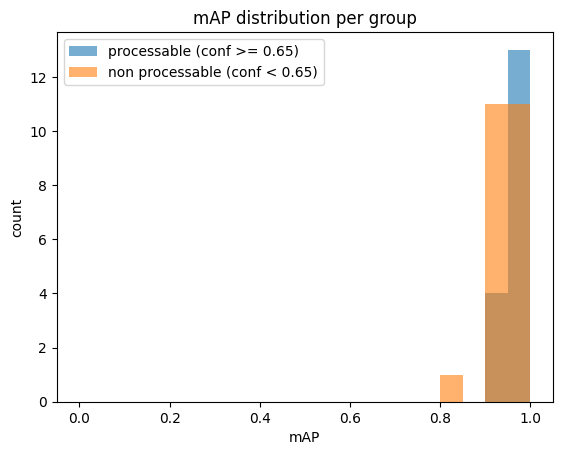

In [107]:
high = df[df["confidence"] >= CONF_THRESHOLD]
low = df[df["confidence"] < CONF_THRESHOLD]

plt.figure()
plt.hist(high["map"], bins=20, range=(0, 1), alpha=0.6,
         label=f"processable (conf >= {CONF_THRESHOLD})")
plt.hist(low["map"], bins=20, range=(0, 1), alpha=0.6,
         label=f"non processable (conf < {CONF_THRESHOLD})")
plt.xlabel("mAP")
plt.ylabel("count")
plt.title("mAP distribution per group")
plt.legend()
plt.show()

## ROC and precision / recall

Positive class = good prediction (map >= METRIC_THRESHOLD). Score = global confidence.

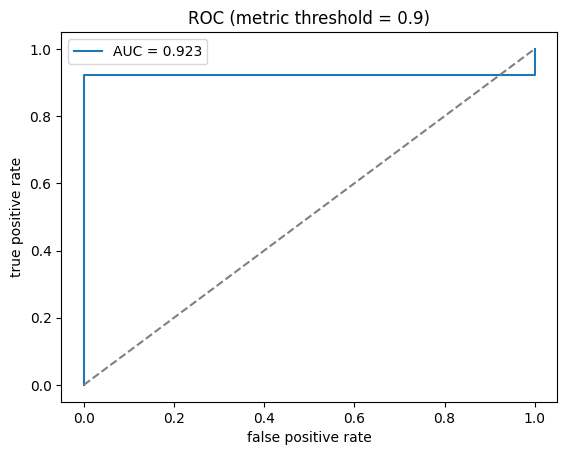

TP=17 FP=0 FN=22 TN=1
precision=1.000 recall=0.436


In [108]:
y_true = (df["map"].values >= METRIC_THRESHOLD).astype(int)
y_score = df["confidence"].values

if y_true.min() != y_true.max():
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("false positive rate")
    plt.ylabel("true positive rate")
    plt.title(f"ROC (metric threshold = {METRIC_THRESHOLD})")
    plt.legend()
    plt.show()
else:
    print("Only one class for this metric threshold, ROC not defined.")

# Precision / recall at the chosen confidence operating point
y_pred = (y_score >= CONF_THRESHOLD).astype(int)
tp = int(np.sum((y_pred == 1) & (y_true == 1)))   # VP: high conf, high map
fp = int(np.sum((y_pred == 1) & (y_true == 0)))   # FP: high conf, low map
fn = int(np.sum((y_pred == 0) & (y_true == 1)))   # FN: low conf, high map
tn = int(np.sum((y_pred == 0) & (y_true == 0)))   # VN: low conf, low map
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
print(f"TP={tp} FP={fp} FN={fn} TN={tn}")
print(f"precision={precision:.3f} recall={recall:.3f}")

## confidence threshold vs metric threshold

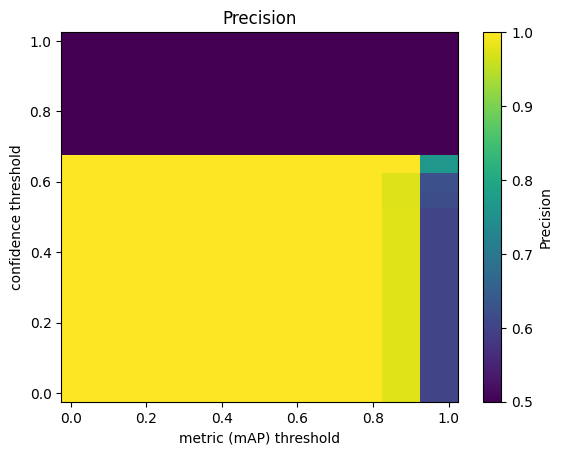

In [113]:
# Positive class = good prediction (map >= metric threshold).
# Predicted positive = processable (confidence >= confidence threshold).
conf_thrs = np.round(np.arange(0.0, 1.0 + 1e-9, 0.05), 2)
metric_thrs = np.round(np.arange(0.0, 1.0 + 1e-9, 0.05), 2)

conf = df["confidence"].values
mp = df["map"].values

auc_grid = np.zeros((len(conf_thrs), len(metric_thrs)))
prec_grid = np.zeros((len(conf_thrs), len(metric_thrs)))

for i, ct in enumerate(conf_thrs):
    pred_pos = conf >= ct
    for j, mt in enumerate(metric_thrs):
        true_pos = mp >= mt
        tp = np.sum(pred_pos & true_pos)
        fp = np.sum(pred_pos & ~true_pos)
        fn = np.sum(~pred_pos & true_pos)
        tn = np.sum(~pred_pos & ~true_pos)
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        auc_grid[i, j] = (tpr + (1 - fpr)) / 2     # area under the single operating point ROC
        prec_grid[i, j] = tp / (tp + fp) if (tp + fp) > 0 else 0.0

for grid, title in [#(auc_grid, "ROC "),
                    (prec_grid, "Precision")]:
    plt.figure()
    plt.pcolormesh(metric_thrs, conf_thrs, grid, cmap="viridis",
                   vmin=0.5, vmax=1, shading="auto")
    plt.colorbar(label=title)
    plt.xlabel("metric (mAP) threshold")
    plt.ylabel("confidence threshold")
    plt.title(title)
    plt.show()

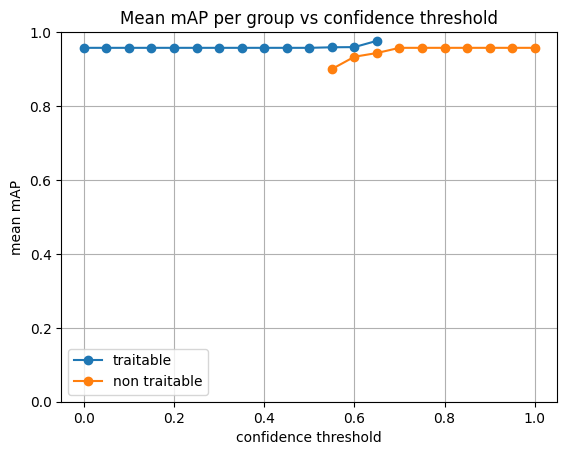

In [115]:
map_traitable = np.full(len(conf_thrs), np.nan)
map_non_traitable = np.full(len(conf_thrs), np.nan)

for i, ct in enumerate(conf_thrs):
    high = conf >= ct          # traitable
    low = ~high                # non traitable
    if high.sum() > 0:
        map_traitable[i] = mp[high].mean()
    if low.sum() > 0:
        map_non_traitable[i] = mp[low].mean()

plt.figure()
plt.plot(conf_thrs, map_traitable, marker="o", label="traitable")
plt.plot(conf_thrs, map_non_traitable, marker="o", label="non traitable")
plt.xlabel("confidence threshold")
plt.ylabel("mean mAP")
plt.title("Mean mAP per group vs confidence threshold")
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

## File names in the four groups

In [111]:
high_conf = df["confidence"].values >= CONF_THRESHOLD
high_map = df["map"].values >= METRIC_THRESHOLD

groups = {
    "VP": df["image"][high_conf & high_map],    # high confidence, high mAP
    "FP": df["image"][high_conf & ~high_map],   # high confidence, low mAP
    "VN": df["image"][~high_conf & ~high_map],  # low confidence, low mAP
    "FN": df["image"][~high_conf & high_map],   # low confidence, high mAP
}

for name, files in groups.items():
    print(f"{name} ({len(files)}):")
    for f in files.tolist():
        print("  ", f)

VP (17):
   EA1.1RV.jpg
   EA3.1A3.jpg
   EA4.0O9.jpg
   EA4.11V.jpg
   EA4.1AI.jpg
   EA6.12T.jpg
   EA8.1EY.jpg
   EA8.1KO.jpg
   F.12745.jpg
   F.31800.jpg
   F.32363.jpg
   F.34863.jpg
   F.34877.jpg
   F.36329.jpg
   F.39503.jpg
   F.39606.jpg
   F.39791.jpg
FP (0):
VN (1):
   F.1015.jpg
FN (22):
   EA1.16A.jpg
   EA1.1RG.jpg
   EA1.1YX.jpg
   EA2.05J.jpg
   EA3.10Q.jpg
   EA4.0OC.jpg
   EA4.1FW.jpg
   EA4.1IS.jpg
   EA5.22U.jpg
   EA7.112.jpg
   EA8.1B9.jpg
   EA8.1NZ.jpg
   EB1.02V.jpg
   EB1.050.jpg
   F.10086.jpg
   F.13681.jpg
   F.15688.jpg
   F.17877.jpg
   F.37860.jpg
   F.38114.jpg
   F.38591.jpg
   F.41741.jpg
